In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.segmentation import slic
from skimage import segmentation

## Lectura de la imagen

(-0.5, 255.5, 255.5, -0.5)

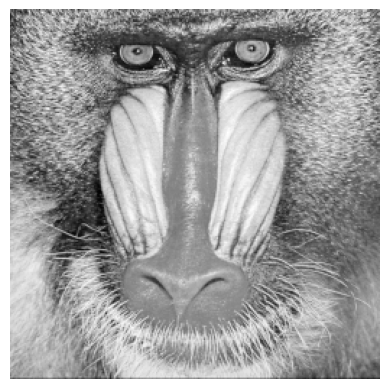

In [6]:
baboon = cv2.imread("images/baboon.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(baboon, cmap='gray')
plt.axis('off')

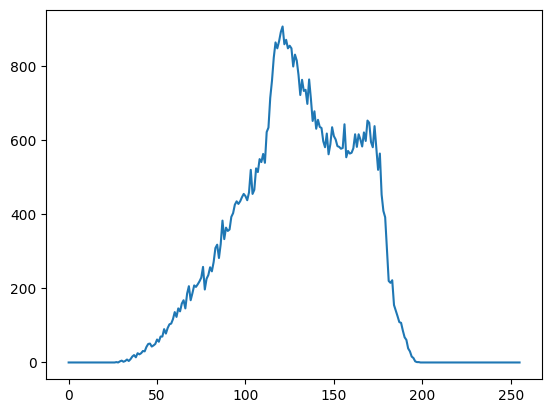

In [7]:
hist= cv2.calcHist([baboon], [0], None, [256], [0, 256])
plt.plot(hist)

## K-Means

In [8]:
img_flat = baboon.reshape(baboon.shape[0]*baboon.shape[1],1)
model_kmeans = KMeans(n_clusters=3)
segmented_image = model_kmeans.fit(img_flat).labels_.reshape(baboon.shape[0],baboon.shape[1],1)

(-0.5, 255.5, 255.5, -0.5)

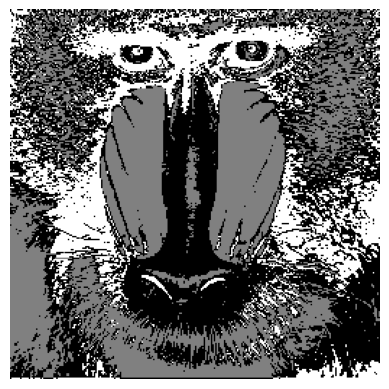

In [9]:
plt.imshow(segmented_image, cmap='gray')
plt.axis('off')

## Método del Codo

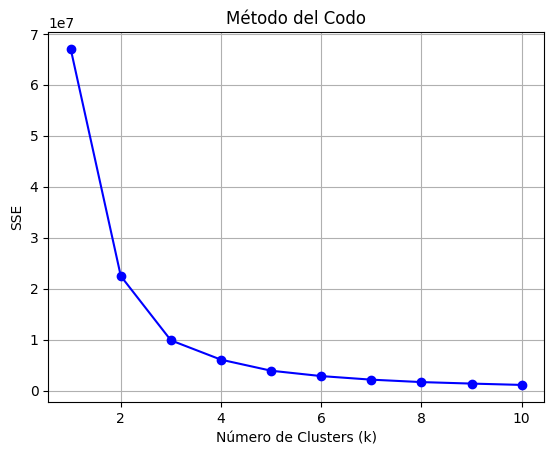

In [10]:
sse = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(img_flat)
    sse.append(kmeans.inertia_)


plt.plot(k_values, sse, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('SSE')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

### ¿Cómo cambia la segmentación?

Según el método del codo el número optimo de clusters es tres. Antes del codo la imagen se dibide únicamente en dos clusters, generando una imagen binaria y perdiendo detalles. Al tener tres clusters la imagen puede dividirse en negros, blancos y grises, lo que permite ver la imagen con suficiente claridad. Al usar más de tres clusters, la gráfica muestra que no se gana mayor detalle (Al ser sus SSE muy similares), y considerando el costo computacional que trae usar más clusters, se vuelven no óptimos.

## Súper-pixeles (SLIC)

Número de súper-píxeles encontrados: 25


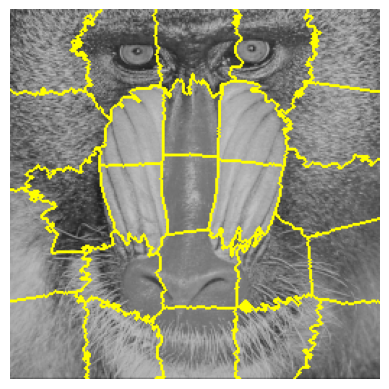

In [11]:
segments = slic(baboon, n_segments=25, compactness=0.5, channel_axis=None)

plt.imshow(segmentation.mark_boundaries(baboon, segments), cmap='gray')
plt.axis('off')

num_superpixels = len(np.unique(segments))
print(f'Número de súper-píxeles encontrados: {num_superpixels}')

### ¿Cuántos súperpixeles se encontraron?
Se encontraron 25 súper pixeles. Se adaptó el parámetro compactness para que coincidira con el valor solicitado

## Súper pixeles óptimo

Número de súper-píxeles encontrados: 4


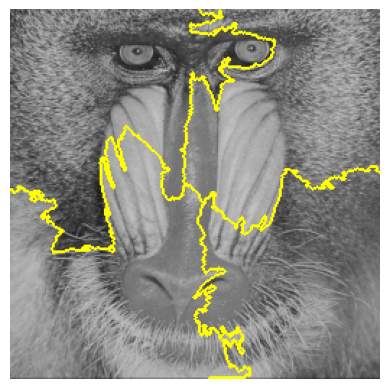

In [12]:
segments = slic(baboon, n_segments=3, compactness=0.5, channel_axis=None)

plt.imshow(segmentation.mark_boundaries(baboon, segments), cmap='gray')
plt.axis('off')

num_superpixels = len(np.unique(segments))
print(f'Número de súper-píxeles encontrados: {num_superpixels}')

Número de súper-píxeles encontrados: 9


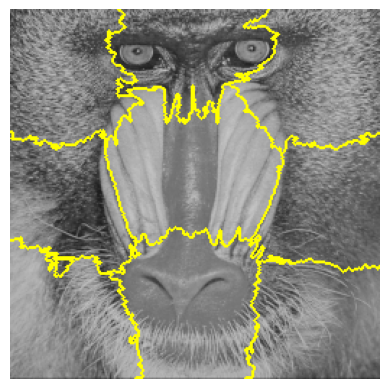

In [13]:
segments = slic(baboon, n_segments=12, compactness=0.5, channel_axis=None)

plt.imshow(segmentation.mark_boundaries(baboon, segments), cmap='gray')
plt.axis('off')

num_superpixels = len(np.unique(segments))
print(f'Número de súper-píxeles encontrados: {num_superpixels}')

Número de súper-píxeles encontrados: 25


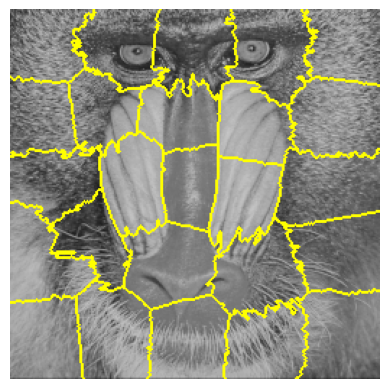

In [14]:
segments = slic(baboon, n_segments=30, compactness=0.5, channel_axis=None)

plt.imshow(segmentation.mark_boundaries(baboon, segments), cmap='gray')
plt.axis('off')

num_superpixels = len(np.unique(segments))
print(f'Número de súper-píxeles encontrados: {num_superpixels}')

### ¿Qué puede observar? ¿Qué diferencias hay entre las imágenes generadas? 

Al comparar las tres segmentaciones con SLIC usando diferentes valores de n_segments (3, 12 y 30) es claro que la división con 12 segmentos es la que tiene más sentido al ojo. Las segmentaciones generaron 4, 9 y 25 súper pixeles respectivamente. La división en 3 segmentos ignora detalles significativos de la imagen, por otro lado, la división en 30 segmentos sobre divide la imagen y las secciones que genera no son significativas. Finalmente la división en 12 fragmentos muestra secciones significativas sin perder detalle.

### ¿Cuál es la diferencia entre las dos técnicas de segmentación por agrupación utilizadas? ¿Cuál presenta el mejor resultado?  ¿Conclusión?

La técnica de segmentación por K-means se hace a partir de la creación de clusters por similitud en la intensidad del pixel, mientras que SLIC también toma en cuenta la intensidad del pixel. Esto hace que SLIC sea teóricamente más precisa. K-means genera una imagen distinta en cada oportunidad, debido a que funciona a partir de la forma aleatória en la que se dividen sus clusters, por el contrario SLIC genera divisiones casi exactas en cara iteración (según las pruebas realizadas). SLIC con 12 segmentos presentó los mejores resultados, aunque K-means presentó mejores resultados que SLIC con 3, 25 y 30 segmentos. En conclusión, SLIC es una gran opción para segmentar imagenes si se conoce el número correcto de segmentaciones. Igualmente K-means es una gran opción principakmente cuando la imagen original cuenta con una división de colores marcada.
